# GDELT news-tone toolkit — for the Lloyds SME lead-scoring pipeline

Turns **GDELT news coverage** into two signals — **tone (sentiment)** = *how* a topic is talked
about, and **volume (attention)** = *how much* it is covered. In the wider project these become a
**sector × region-level feature** that sits beside the Companies House features feeding the
lead-scoring model.

> ⚠️ GDELT only covers *news*, and individual SMEs are almost never in the news. So this is a
> **sector / region climate** signal (join to each firm by SIC group + region) — **not** a
> per-company one.

## Two routes — pick by scale

| | **DOC API** (Part 1) | **BigQuery / GKG** (Parts 2–4) |
|---|---|---|
| Best for | **one theme**, quick / ad-hoc | **many themes / sectors** at once |
| Matching | exact free-text keywords | GKG **theme names** (approximate) |
| Geography | source country only | real **`V2Locations`** (UK regions) |
| History | ~1 year | full (2015 → now) |
| Limit to watch | per-IP **rate limit (429)** | **bytes scanned** (cost) |
| Setup | none (free & keyless) | GCP project + auth |

**Rule of thumb:** *single theme / no cloud* → DOC API · *many sectors, geography, or long history* → BigQuery.

### Contents
1. **Part 1 — DOC API:** robust client + a single-theme **tone & volume** example.
2. **Part 2 — BigQuery:** the same single theme — full history + real UK-region geography, **tone & volume** (Query A, Query B).
3. **Part 3 — BigQuery:** all sectors in one scan — funding-sentiment **tone & volume z-scores**.
4. **Part 4 — BigQuery:** sector **×** region wired together — the **joinable context-media index** (per-cell point-in-time z-scores, sector-only fallback for thin cells).
5. **Part 5 — postcodes.io:** company postcode → **town + region**, the join key that connects each SME to the Part 4 index.

---

## Part 1 · DOC API — single theme, cloud-free

The DOC 2.0 API is **free and keyless.** Its one real catch is **rate limiting**: GDELT throttles **per IP** to
~1 request / 5 s, and a burst drops your IP into an **extended penalty box** (minutes) that returns
`HTTP 429`. The client in the next cells handles this so a run won't just crash:

1. a **global throttle** — a minimum gap before *every* request, even across cells;
2. **exponential backoff + jitter** on 429, plus a `cooldown()` helper for the deep penalty box;
3. robust handling of GDELT's quirks (plain-text errors behind HTTP 200, empty bodies, the
   mandatory browser User-Agent).

Sources: [DOC 2.0 API](https://blog.gdeltproject.org/gdelt-doc-2-0-api-debuts/) ·
[API quotas](https://blog.gdeltproject.org/behind-the-scenes-api-quotas-the-impact-of-a-fraction-of-a-qps/) ·
[User-Agent fix](https://github.com/alex9smith/gdelt-doc-api/issues/22)

In [2]:
import os, time, random, threading
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# ---------------------------------------------------------------------------
# Robust GDELT DOC 2.0 client
# ---------------------------------------------------------------------------
DOC_BASE = "https://api.gdeltproject.org/api/v2/doc/doc"

# A real browser User-Agent is MANDATORY — GDELT returns 429 to non-browser clients.
HEADERS = {
    "User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                   "AppleWebKit/537.36 (KHTML, like Gecko) "
                   "Chrome/124.0 Safari/537.36"),
    "Accept": "application/json",
}

# >>> THE LAG KNOB YOU <<<
# MIN_INTERVAL is the minimum gap enforced *before every request*, GLOBALLY and
# *across cells* (the timer lives in _LAST_CALL, which survives between cell runs).
# So two helper calls in a row (e.g. timeline_tone() then timeline_volume()) are
# already spaced by this value automatically — no manual time.sleep() needed.
# GDELT's floor is ~5 s; raise this if you still trip the limit on a clean IP.
MIN_INTERVAL = 10.0         # seconds enforced *before* every request (was 6)
_LAST_CALL = [0.0]
_LOCK = threading.Lock()


def _throttle():
    """Block until at least MIN_INTERVAL has passed since the previous request."""
    with _LOCK:
        gap = MIN_INTERVAL - (time.monotonic() - _LAST_CALL[0])
        if gap > 0:
            time.sleep(gap)
        _LAST_CALL[0] = time.monotonic()


def cooldown(minutes=15):
    """Sit idle (making NO requests) to let GDELT's per-IP penalty box expire.

    Run this cell when you keep getting 429s even on a single well-spaced call.
    Once GDELT has penalised your IP, *every* further request can prolong the
    block, so the only reliable cure is to stop calling GDELT entirely for a
    while and THEN make one request. Do not Ctrl+C a backoff and immediately
    rerun — that is what keeps you stuck.
    """
    print(f"Cooling down for {minutes} min with zero GDELT requests...")
    time.sleep(int(minutes * 60))
    _LAST_CALL[0] = 0.0  # reset throttle clock so the next call fires right away
    print("Cooldown done. Now run ONE timeline_tone() call and let it finish "
          "without interrupting it.")


def _get(params, base_url=DOC_BASE, max_retries=6, base_pause=12.0,
         max_pause=180.0, verbose=True):
    """GET a GDELT endpoint with throttling + exponential backoff and jitter.

    Handles GDELT's failure modes:
      * HTTP 429              -> rate-limited / penalty box  (retry with backoff)
      * 200 + plain-text body -> bad query or transient error
      * 200 + empty body      -> transient                  (retry)
    Raises RuntimeError with a clear message if it never succeeds.

    NOTE on 429s: GDELT can drop an IP into an *extended* penalty box (minutes)
    after a burst, and hitting it again while penalised can prolong it. The
    backoff therefore grows quickly and waits up to `max_pause` seconds between
    attempts so the penalty has time to clear rather than being repoked. Worst
    case here is ~9 min (12+24+48+96+180+180s) before giving up with a clear
    message. If you hit that wall, run cooldown() and try again later — and note
    that on a SHARED IP (corporate/uni network) the limit is consumed by everyone
    on that network, so client-side pacing alone may not be enough.
    """
    last_err = None
    for attempt in range(max_retries):
        _throttle()
        try:
            r = requests.get(base_url, params=params, headers=HEADERS, timeout=30)
        except requests.RequestException as e:
            last_err = e
            if verbose:
                print(f"  network error: {e} (attempt {attempt + 1}/{max_retries})")
            time.sleep(base_pause)
            continue

        if r.status_code == 429:
            ra = r.headers.get("Retry-After")
            if ra and ra.isdigit():
                pause = float(ra)
            else:
                pause = base_pause * (2 ** attempt)              # exponential
            pause = min(pause, max_pause) + random.uniform(0, base_pause)  # + jitter
            last_err = RuntimeError("HTTP 429 rate-limited")
            if verbose:
                print(f"  429 rate-limited; backing off {pause:.0f}s "
                      f"(attempt {attempt + 1}/{max_retries})  "
                      f"[do NOT interrupt + rerun — that prolongs the block]")
            time.sleep(pause)
            continue

        r.raise_for_status()
        ctype = r.headers.get("content-type", "")
        if "json" not in ctype:
            body = r.text.strip()
            if not body:                       # empty -> transient, retry
                last_err = RuntimeError("empty response body")
                if verbose:
                    print(f"  empty body; retrying (attempt {attempt + 1}/{max_retries})")
                time.sleep(base_pause)
                continue
            # non-empty, non-JSON -> a genuine query error; don't waste retries
            raise RuntimeError(f"GDELT rejected the query: {body[:200]}")
        return r.json()

    raise RuntimeError(
        f"GDELT still unavailable after {max_retries} attempts ({last_err}). "
        "Your IP is in GDELT's penalty box. Run cooldown(), wait, then rerun ONE "
        "cell. On a shared/corporate IP, consider BigQuery (gdelt-bq) instead."
    )

In [4]:
# ---------------------------------------------------------------------------
# Query builder + timeline helpers
# ---------------------------------------------------------------------------
def build_query(phrase=None, keyword=None, sourcecountry=None, sourcelang=None,
                theme=None, domain=None, extra=None):
    """Assemble a GDELT DOC query string from common filters.

    Region filter:
      * sourcecountry -> country the *outlet* is based in (FIPS code or name),
        e.g. "UK", "US", or "unitedkingdom". This is the DOC API's real
        geographic filter.

    NOTE: GDELT requires at least one actual search term (a phrase/keyword);
    a query made of only operators (e.g. just `sourcecountry:UK`) is rejected.
    """
    parts = []
    if phrase:
        parts.append(f'"{phrase}"')
    if keyword:
        parts.append(keyword)
    if sourcecountry:
        parts.append(f"sourcecountry:{sourcecountry}")
    if sourcelang:
        parts.append(f"sourcelang:{sourcelang}")
    if theme:
        parts.append(f"theme:{theme}")
    if domain:
        parts.append(f"domain:{domain}")
    if extra:
        parts.append(extra)
    if not (phrase or keyword):
        raise ValueError("GDELT needs at least a phrase or keyword, not only filters.")
    return " ".join(parts).strip()


def timeline_tone(query, timespan="14d", smooth=None, **extra):
    """Average-tone timeline for articles matching `query`.

    Tone runs ~ -100..+100 (most values -10..+10): negative = unfavourable
    coverage, 0 = neutral, positive = favourable. Returns DataFrame [date, tone].
    `smooth` (int) applies GDELT's moving-average smoothing over N points.
    """
    params = {"query": query, "mode": "timelinetone",
              "format": "json", "timespan": timespan, **extra}
    if smooth:
        params["timelinesmooth"] = int(smooth)
    data = _get(params)
    tl = data.get("timeline", [])
    series = tl[0].get("data", []) if tl else []
    df = pd.json_normalize(series)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
        df = df.rename(columns={"value": "tone"})[["date", "tone"]]
    return df


def timeline_volume(query, timespan="14d", **extra):
    """Daily volume-of-coverage timeline. Returns DataFrame [date, value]."""
    params = {"query": query, "mode": "timelinevol",
              "format": "json", "timespan": timespan, **extra}
    data = _get(params)
    tl = data.get("timeline", [])
    series = tl[0].get("data", []) if tl else []
    df = pd.json_normalize(series)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
    return df


def article_search(query, timespan="7d", maxrecords=25, **extra):
    """Matching articles as a DataFrame (seendate, title, domain, url, ...)."""
    params = {"query": query, "mode": "artlist", "format": "json",
              "timespan": timespan, "maxrecords": maxrecords, **extra}
    data = _get(params)
    return pd.json_normalize(data.get("articles", []))

### Part 1 example — one theme's tone *and* volume (and what "region" means)

The next cell is the DOC API's sweet spot: **one exact-keyword query**. For `Information Technology
funding` in **UK-published** media (last month) it pulls **two timelines**:

- **tone** (`timeline_tone`) — the *emotion* of the coverage (≈ −10…+10; negative = unfavourable);
- **volume** (`timeline_volume`) — the *attention*: how much coverage there is, as a % of all GDELT output.

Read them together — tone says *how* the sector is being talked about, volume says *how loudly*. (Two
separate API calls; the global throttle spaces them automatically, no manual `sleep` needed.)

**Heads-up — "region" means two different things in GDELT:**

**1. Source region — where the article is PUBLISHED — `sourcecountry`** (this is what the example uses).
Supported directly by the DOC API; FIPS 10-4 code or lowercased name:

| Country | code |  | Country | code |
|---|---|---|---|---|
| United Kingdom | `UK` |  | Japan | `JA` |
| United States | `US` |  | Germany | `GM` |
| France | `FR` |  | China | `CH` |
| Australia | `AS` |  | India | `IN` |

**2. Subject region — the place the story is ABOUT** (London, Bristol, the North East). The DOC API
**can't** do this (no `V2Locations` operator) → it's handled in **Part 2 · Query B**, which reads
*real* geolocation from GKG.

Query: Information Technology funding sourcecountry:UK
  429 rate-limited; backing off 14s (attempt 1/6)  [do NOT interrupt + rerun — that prolongs the block]
  429 rate-limited; backing off 13s (attempt 1/6)  [do NOT interrupt + rerun — that prolongs the block]
  429 rate-limited; backing off 31s (attempt 2/6)  [do NOT interrupt + rerun — that prolongs the block]
  429 rate-limited; backing off 57s (attempt 3/6)  [do NOT interrupt + rerun — that prolongs the block]
Tone points: 30   Volume points: 30
                     date    tone
2026-06-21 00:00:00+00:00  0.0000
2026-06-22 00:00:00+00:00  0.1909
2026-06-23 00:00:00+00:00  0.7540
2026-06-24 00:00:00+00:00 -0.2838
2026-06-25 00:00:00+00:00  0.6712

Average tone over period:   0.64   (negative = unfavourable)
Average volume over period: 0.0027  (% of all GDELT coverage = attention)


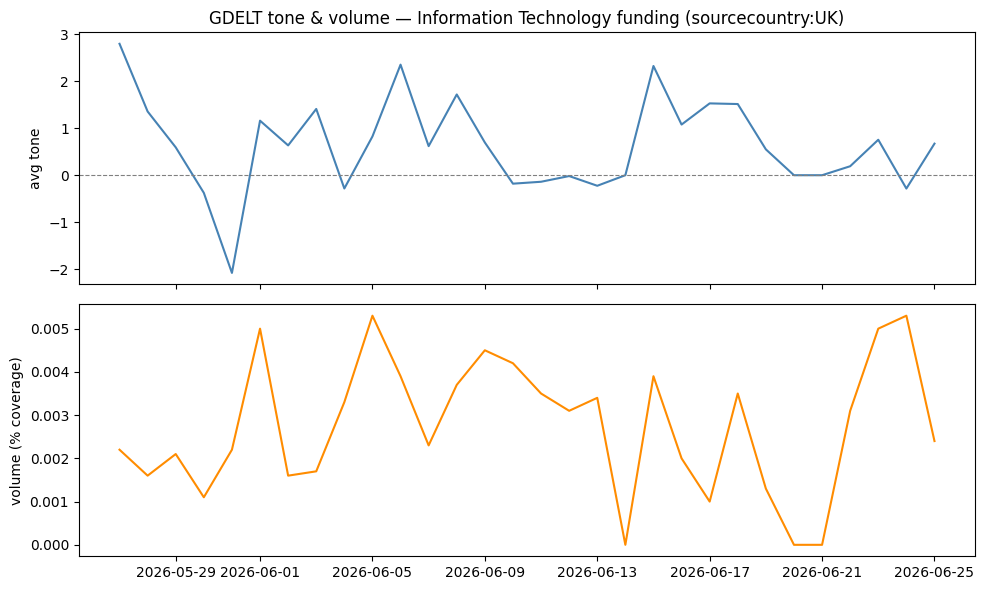

In [42]:
# ---------------------------------------------------------------------------
# Example: tone AND volume for "Information Technology" + "funding" (UK media).
# keyword= means AND (both words must appear). Use phrase= ONLY for an exact
# adjacent phrase like "construction funding", which is far rarer (often 0 hits).
# Two timelines = two API calls; the global throttle spaces them automatically.
# ---------------------------------------------------------------------------
SEARCH_TERMS = "Information Technology funding"     # space = AND -> both words required
SOURCE_COUNTRY = "UK"

q = build_query(keyword=SEARCH_TERMS, sourcecountry=SOURCE_COUNTRY)
print("Query:", q)

tone = timeline_tone(q, timespan="1m")       # emotion of the coverage
vol  = timeline_volume(q, timespan="1m")     # attention: amount of coverage
print(f"Tone points: {len(tone)}   Volume points: {len(vol)}")

if not tone.empty:
    print(tone.tail().to_string(index=False))
    print(f"\nAverage tone over period:   {tone['tone'].mean():.2f}   (negative = unfavourable)")
if not vol.empty:
    print(f"Average volume over period: {vol['value'].mean():.4f}  "
          "(% of all GDELT coverage = attention)")

# Tone (top) vs volume (bottom) on a shared time axis: how it's talked about vs how loudly.
if not tone.empty or not vol.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    if not tone.empty:
        ax1.plot(tone["date"], tone["tone"], color="steelblue")
    ax1.axhline(0, color="grey", lw=0.8, ls="--")
    ax1.set_ylabel("avg tone")
    ax1.set_title(f"GDELT tone & volume — {SEARCH_TERMS} (sourcecountry:{SOURCE_COUNTRY})")
    if not vol.empty:
        ax2.plot(vol["date"], vol["value"], color="darkorange")
    ax2.set_ylabel("volume (% coverage)")
    plt.tight_layout()
    plt.show()

## Part 2 · BigQuery — the same theme, but full history + real geography

Identical signals to Part 1 — **tone** (sentiment) and **volume** (attention) — run against **GKG in
BigQuery** instead of the HTTP API, so **no rate limits**, **full history (2015 → now)**, and **real
`V2Locations`** geography. Use this whenever the DOC API's rate limit gets in the way, or you need
geolocation / long history.

**This part runs two single-theme queries:**
- **Query A** — daily **tone** (emotion) *and* **volume** (attention, articles/day) for the theme —
  the `timelinetone`-equivalent; it prints average tone *and* average articles/day, and plots both.
- **Query B** — the UK **regions** the coverage is *about*, from real `V2Locations` mentions, with
  both **tone** and **mention-count** (attention) per region.

### One-time setup
1. A **GCP project** (the free **Sandbox** is fine — no card) with the **BigQuery API** enabled.
2. Auth: `gcloud auth application-default login` (local) **or** a service-account key
   (`GOOGLE_APPLICATION_CREDENTIALS`) for an automated job.
3. `pip install google-cloud-bigquery db-dtypes pandas matplotlib`
4. Set `PROJECT` in the next cell.

### Cost model — you pay by **bytes scanned**, not rows
- We query the **partitioned** table `gdelt-bq.gdeltv2.gkg_partitioned` and filter `_PARTITIONTIME`
  so only the needed days are scanned (the plain `gkg` is **3.6 TB**).
- `bq_query()` does a **free dry run first**, prints the GB it *would* scan, and **aborts if it
  exceeds `max_gb`** — nothing is billed until you're under budget. Free tier = **1 TB/month**.

### Matching note
BigQuery has no article body text, so themes are matched on GKG **theme names** (`V2Themes`) —
*approximate*, not literal words. When you need exact words, drop back to the DOC API (Part 1).

In [5]:
# --- BigQuery hybrid route: imports + client -------------------------------
# Run once:  pip install google-cloud-bigquery db-dtypes pandas matplotlib
import datetime as dt
import re
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

PROJECT = "lloyds-gdelt"   # <-- set your GCP project (billing must be enabled)

try:
    client = bigquery.Client(project=PROJECT) # opens an authenticated session tied to your project.
    print("BigQuery client ready for project:", client.project)
except Exception as e:
    client = None
    print("BigQuery client NOT ready — finish the setup steps in the markdown above.\n ",
          type(e).__name__, ":", e)

BigQuery client ready for project: lloyds-gdelt


In [7]:
# --- Config + helpers ------------------------------------------------------
GKG = "`gdelt-bq.gdeltv2.gkg_partitioned`"   # partitioned table = cheap date pruning

# Run window. For a weekly job this is "the last 7 days".
END_D   = dt.date.today()
START_D = END_D - dt.timedelta(days=7)

# Theme approximation of your free-text intent ("construction" + "funding").
# Each inner list = OR (a theme NAME contains any token); the groups are AND-ed.
# Refine these tokens against LOOKUP-GKGTHEMES.TXT, then spot-check matching URLs.
THEME_FILTERS = [
    ["INFORMATION", "TECHNOLOGY", "DIGITAL"],
    ["FUND", "SUBSID", "FINANC", "INVEST", "GRANT"],
]

# UK city -> region rollup (extend freely). Unmapped cities -> "Other / unmapped".
CITY_TO_REGION = {
    "London": "London",
    "Birmingham": "West Midlands", "Coventry": "West Midlands", "Wolverhampton": "West Midlands",
    "Leicester": "East Midlands", "Nottingham": "East Midlands", "Derby": "East Midlands",
    "Manchester": "North West", "Liverpool": "North West", "Preston": "North West", "Bolton": "North West",
    "Leeds": "Yorkshire", "Sheffield": "Yorkshire", "Bradford": "Yorkshire", "York": "Yorkshire", "Hull": "Yorkshire",
    "Newcastle": "North East", "Sunderland": "North East", "Durham": "North East", "Middlesbrough": "North East",
    "Bristol": "South West", "Plymouth": "South West", "Exeter": "South West", "Bath": "South West", "Gloucester": "South West",
    "Southampton": "South East", "Portsmouth": "South East", "Brighton": "South East", "Oxford": "South East", "Reading": "South East",
    "Norwich": "East of England", "Cambridge": "East of England", "Ipswich": "East of England", "Peterborough": "East of England",
    "Glasgow": "Scotland", "Edinburgh": "Scotland", "Aberdeen": "Scotland", "Dundee": "Scotland",
    "Cardiff": "Wales", "Swansea": "Wales", "Newport": "Wales",
    "Belfast": "Northern Ireland", "Derry": "Northern Ireland",
}


def theme_where(groups, col="V2Themes"):
    """Build a sanitized '(.. OR ..) AND (.. OR ..)' theme filter from token groups."""
    parts = []
    for grp in groups:
        ors = []
        for tok in grp:
            assert re.fullmatch(r"[A-Z0-9_]+", tok), f"bad theme token: {tok!r}"
            ors.append(f"{col} LIKE '%{tok}%'")
        parts.append("(" + " OR ".join(ors) + ")")
    return " AND ".join(parts) if parts else "TRUE"


def date_params(start_d, end_d):
    """Partition + DATE-column params for cost-pruned, inclusive date filtering."""
    return [
        bigquery.ScalarQueryParameter("pstart", "TIMESTAMP", f"{start_d} 00:00:00"),
        bigquery.ScalarQueryParameter("pend", "TIMESTAMP",
                                      f"{end_d + dt.timedelta(days=1)} 00:00:00"),
        bigquery.ScalarQueryParameter("dstart", "INT64",
                                      int(start_d.strftime('%Y%m%d')) * 1000000),
        bigquery.ScalarQueryParameter("dend", "INT64",
                                      int(end_d.strftime('%Y%m%d')) * 1000000 + 235959),
    ]


def bq_query(sql, params=None, max_gb=5.0, run=True):
    """Dry-run first (print GB scanned), abort if > max_gb, else run -> DataFrame.

    The dry run is free and is your cost seatbelt: it tells you how many GB the
    query WILL scan before a single byte is billed. max_gb is a hard ceiling.
    """
    if client is None:
        raise RuntimeError("BigQuery client not initialised — see the setup cell.")
    cfg = bigquery.QueryJobConfig(query_parameters=params or [],
                                  dry_run=True, use_query_cache=False)
    gb = client.query(sql, job_config=cfg).total_bytes_processed / 1e9
    print(f"Dry run: ~{gb:.2f} GB will be scanned (free tier = 1000 GB/month).")
    if gb > max_gb:
        raise RuntimeError(f"Query would scan {gb:.2f} GB > max_gb={max_gb}. "
                           "Tighten the date range/filters, or raise max_gb if intended.")
    if not run:
        return None
    cfg = bigquery.QueryJobConfig(query_parameters=params or [])
    return client.query(sql, job_config=cfg).to_dataframe()

Dry run: ~3.73 GB will be scanned (free tier = 1000 GB/month).


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


       day  articles  avg_tone
2026-06-18      1415 -0.923561
2026-06-19      1299 -1.839003
2026-06-20       850 -2.057266
2026-06-21       587 -2.225877
2026-06-22      1239 -1.155629
2026-06-23      1776 -1.461269
2026-06-24      1183 -1.208495
2026-06-25      1011 -1.065616

Average tone over window:   -1.49   (negative = unfavourable)
Average volume over window: 1170.0 articles/day  (attention)


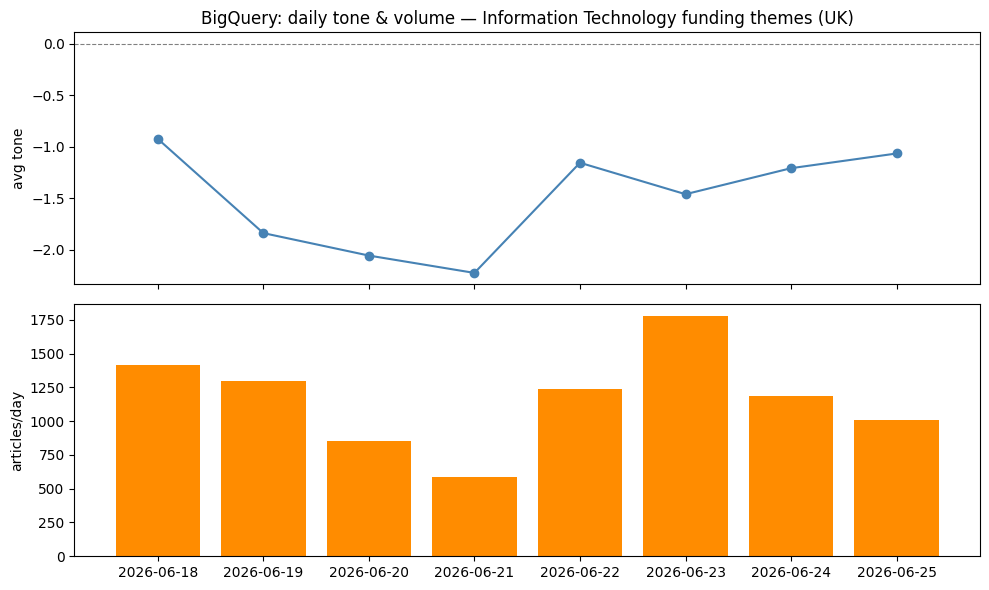

In [49]:
# --- Query A: daily tone + volume (the timelinetone-equivalent) -------------
sql_timeline = f"""
SELECT
  PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
  COUNT(*) AS articles,
  AVG(SAFE_CAST(SPLIT(V2Tone, ',')[SAFE_OFFSET(0)] AS FLOAT64)) AS avg_tone
FROM {GKG}
WHERE _PARTITIONTIME >= TIMESTAMP(@pstart) AND _PARTITIONTIME < TIMESTAMP(@pend)
  AND DATE >= @dstart AND DATE <= @dend
  AND V2Locations LIKE '%#UK#%'             -- coverage that mentions the UK
  AND {theme_where(THEME_FILTERS)}
GROUP BY day
ORDER BY day
"""

tl = bq_query(sql_timeline, params=date_params(START_D, END_D), max_gb=5.0)
print(tl.to_string(index=False))
if not tl.empty:
    tl["day"] = pd.to_datetime(tl["day"])
    print(f"\nAverage tone over window:   {tl['avg_tone'].mean():.2f}   (negative = unfavourable)")
    print(f"Average volume over window: {tl['articles'].mean():.1f} articles/day  (attention)")
    # Tone (top) vs volume (bottom) on a shared time axis.
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax1.plot(tl["day"], tl["avg_tone"], marker="o", color="steelblue")
    ax1.axhline(0, color="grey", lw=0.8, ls="--")
    ax1.set_ylabel("avg tone")
    ax1.set_title(f"BigQuery: daily tone & volume — {SEARCH_TERMS} themes (UK)")
    ax2.bar(tl["day"], tl["articles"], color="darkorange")
    ax2.set_ylabel("articles/day")
    plt.tight_layout(); plt.show()

Dry run: ~3.73 GB will be scanned (free tier = 1000 GB/month).


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


UK regions the Information Technology funding coverage is about:

                  mentions  avg_tone
region                              
Other / unmapped     12841    -2.486
London                6298    -1.974
Scotland              1763     -2.17
North West            1405     -0.09
East Midlands          712    -2.568
Northern Ireland       322    -5.449
East of England        298    -0.683
South West             121     -1.91
South East              27      0.16
North East              20    -0.759
Wales                   15    -5.641


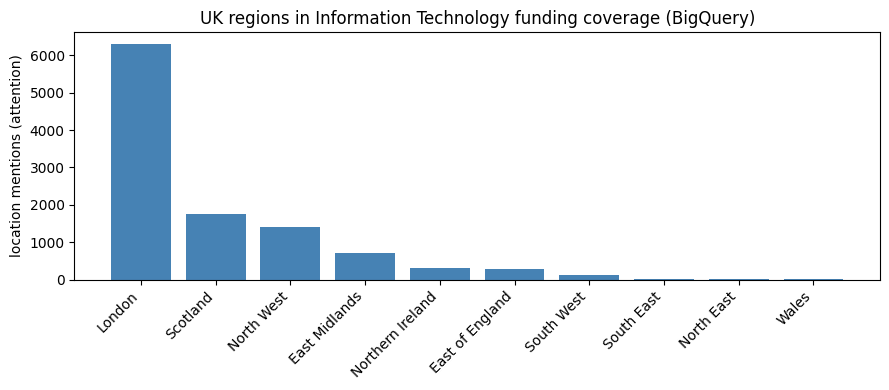

In [50]:
# --- Query B: which UK locations the coverage is ABOUT -> roll up to regions -
# Unnest V2Locations, keep UK city-level mentions (Type >= 3), aggregate tone.
sql_places = f"""
SELECT
  SPLIT(loc, '#')[SAFE_OFFSET(1)] AS place,
  COUNT(*) AS mentions,
  AVG(SAFE_CAST(SPLIT(V2Tone, ',')[SAFE_OFFSET(0)] AS FLOAT64)) AS avg_tone
FROM {GKG}, UNNEST(SPLIT(V2Locations, ';')) AS loc
WHERE _PARTITIONTIME >= TIMESTAMP(@pstart) AND _PARTITIONTIME < TIMESTAMP(@pend)
  AND DATE >= @dstart AND DATE <= @dend
  AND {theme_where(THEME_FILTERS)}
  AND SPLIT(loc, '#')[SAFE_OFFSET(2)] = 'UK'                    -- UK locations only
  AND SAFE_CAST(SPLIT(loc, '#')[SAFE_OFFSET(0)] AS INT64) >= 3  -- city/ADM1, not country
GROUP BY place
ORDER BY mentions DESC
"""

places = bq_query(sql_places, params=date_params(START_D, END_D), max_gb=5.0)

# Map each geolocated city (first token of the full name) -> UK region, in pandas.
places["city"] = places["place"].str.split(",").str[0].str.strip()
places["region"] = places["city"].map(CITY_TO_REGION).fillna("Other / unmapped")

# Coverage-weighted average tone + total attention (mentions) per region.
# (version-portable: named .agg instead of groupby.apply)
places["_wt"] = places["avg_tone"] * places["mentions"]
region = places.groupby("region").agg(mentions=("mentions", "sum"), _wt=("_wt", "sum"))
region["avg_tone"] = (region["_wt"] / region["mentions"]).round(3)
region["mentions"] = region["mentions"].astype(int)
region = region.drop(columns="_wt").sort_values("mentions", ascending=False)

if not region.empty:
    print(f"UK regions the {SEARCH_TERMS} coverage is about:\n")
    print(region.to_string())
    sub = region.drop(index="Other / unmapped", errors="ignore")
    fig, ax = plt.subplots(figsize=(9, 4))                      # explicit ax.bar = robust
    ax.bar(sub.index.astype(str), sub["mentions"], color="steelblue")
    ax.set_title(f"UK regions in {SEARCH_TERMS} coverage (BigQuery)")
    ax.set_ylabel("location mentions (attention)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()

## Part 3 · BigQuery — many themes at once (sector funding-sentiment)

The **many-themes** sweep: instead of one theme, score **every SIC sector in a single BigQuery scan**.
(The DOC API can't do this — one rate-limited request per sector drowns in 429s.)

**Goal:** each week, surface the sectors whose **funding/lending climate is improving** — a
sector-level signal of where SME borrowing demand may be rising (join to each firm by SIC group).

**Why a z-score, not raw averages?** Sectors have different baseline tone *and* very different
article volumes, so raw cross-sector numbers just reflect "which sectors are habitually covered
positively / heavily" + small-sample noise. So we **z-score each sector against its own history**,
which makes the scores comparable across sectors.

**Two z-scores — sentiment *and* attention:**

> `tone_z = (latest-week tone − sector's baseline mean tone) / baseline std`
> `vol_z  = (latest-week articles/day − sector's baseline mean articles/day) / baseline std`

- **`tone_z`** — is sentiment *unusually positive* for this sector right now?
- **`vol_z`** — is this sector getting *unusually much* coverage right now?

The strongest lead signal is a sector high on **both** — improving sentiment *and* rising attention.
The table is ranked by `tone_z`, with `vol_z` beside it (and a grouped bar chart) so you can spot that
combination. A minimum article count stops tiny sectors winning by luck.

> 📏 **Volume is measured per *day*, not per week.** The current week is usually *partial* (e.g. you
> run mid-week), so a raw weekly count — and its z-score — would read artificially low for *every*
> sector. Dividing by the number of days in each week removes that bias (a z-score is scale-invariant,
> so for complete weeks per-day and per-week give the same result; only the partial week is corrected).

**Cost controls in the cell:** `USE_CACHE` re-reads a saved **Parquet** file (0 GB) so you can iterate
the z-scores/plot for free; `DEV_MODE` runs a tiny 4-week window for a cheap smoke test; the dry-run
guard still applies. *(Parquet = a compact, typed, binary table file — like a faster CSV that also
remembers each column's data type.)*

⚠️ **Sector-level only** — GDELT can't see individual SMEs, so this tells you *which sectors* are
heating up, not which firms.

Loaded 594 rows from cache 'sector_weekly_cache_53w.parquet' (0 GB scanned). Set USE_CACHE=False to pull fresh data.

BigQuery — sector funding sentiment & attention, most improved this week (z-scores):

               sector latest_week  latest_articles  latest_tone  baseline_tone  baseline_artic_day  tone_z  vol_z
          Real estate  2026-07-05             2182        -0.28          -0.54               444.7    0.80  -1.03
        Manufacturing  2026-07-05             1166        -0.01          -0.31               214.4    0.72  -0.46
          Hospitality  2026-07-05              629         0.07          -0.31               110.1    0.62  -0.21
  Information & comms  2026-07-05             6826        -1.26          -1.43              1174.2    0.51  -0.19
   Retail & wholesale  2026-07-05              257        -0.19          -0.29                42.2    0.12   0.03
   Financial services  2026-07-05            14465        -1.16          -1.18              2585.6    0.07  -0.4

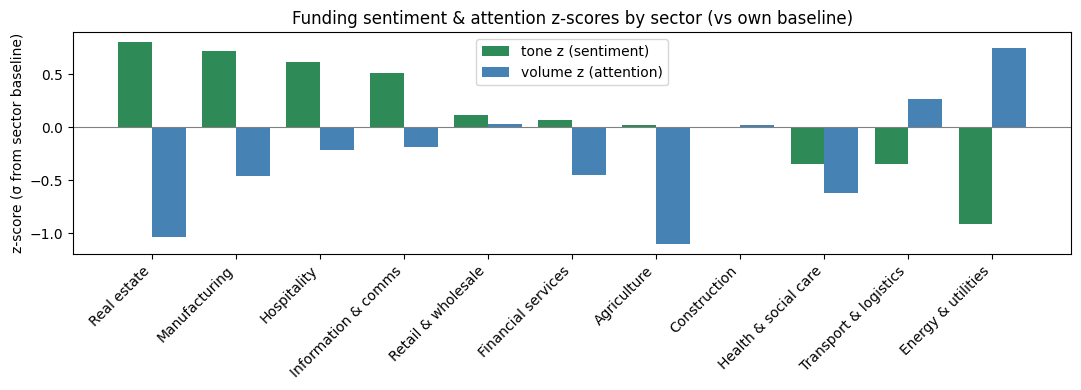

In [11]:
# ===========================================================================
# BigQuery version — ALL sectors in one query, true article counts, baseline z
# ===========================================================================
# --- dev / cost controls (protect your 1 TB/month free tier) ---------------
USE_CACHE = True  # if a cache file exists, load it (0 GB) instead of querying
DEV_MODE  = False    # True -> tiny 4-week window for a cheap real-data smoke test

# Workflow: leave USE_CACHE=True to iterate the z-score/plot for free on cached data.
# Set USE_CACHE=False once to pull fresh data (it overwrites the cache).
# Use DEV_MODE=True for a ~13 GB smoke test; False = full ~85 GB / 26-week run.
# ---------------------------------------------------------------------------
import os

# A row can match several sectors (sectors overlap) — that's expected.
# Sector matching is on V2Themes theme-NAMES (approximate; refine vs LOOKUP-GKGTHEMES).
SECTOR_PATTERNS = {                         # sector -> regex alternation (lowercase)
    "Construction":          "construction|infrastructure|building",
    "Manufacturing":         "manufactur|industrial",
    "Retail & wholesale":    "retail|wholesale|consumer goods",
    "Transport & logistics": "transport|logistic|freight|shipping|aviation",
    "Hospitality":           "hospitality|tourism|restaurant|hotel",
    "Real estate":           "real estate|property|housing",
    "Information & comms":    "telecom|software|information technology|media",
    "Financial services":    "bank|financ|insurance|fintech",
    "Health & social care":  "health|social care|hospital|pharma",
    "Energy & utilities":    "energy|electricity|utilit|renewable",
    "Agriculture":           "agricultur|farming|forestry|fishing",
}
FUNDING_PAT = "fund|investment|financ|lend|loan|subsidy|grant|capital"


def _safe_pat(p):                           # allow only word chars, spaces, '|'
    assert re.fullmatch(r"[a-z0-9 |]+", p), f"unsafe pattern: {p!r}"
    return p


_sector_cte = " UNION ALL ".join(
    f"SELECT '{name}' AS sector, r'{_safe_pat(pat)}' AS pat"
    for name, pat in SECTOR_PATTERNS.items())

# Baseline length drives scan cost: ~3.3 GB/week of GKG text columns.
#   4 wk (dev) ≈ 13 GB  |  26 wk (~6 mo) ≈ 85 GB  |  53 wk (~1 yr) ≈ 174 GB.
BASE_WEEKS = 4 if DEV_MODE else 53
bq_start = END_D - dt.timedelta(weeks=BASE_WEEKS)
CACHE_FILE = f"sector_weekly_cache_{BASE_WEEKS}w.parquet"   # window-specific cache

# We also count DISTINCT days per week so volume can be read as articles/day.
# That matters because the CURRENT week is usually partial (fewer days), which
# would drag a raw weekly count — and its volume z-score — artificially low.
sql_sector = f"""
WITH sectors AS ( {_sector_cte} ),
matched AS (
  SELECT
    s.sector,
    PARSE_DATE('%Y%m%d', SUBSTR(CAST(g.DATE AS STRING), 1, 8)) AS day,
    DATE_TRUNC(PARSE_DATE('%Y%m%d', SUBSTR(CAST(g.DATE AS STRING), 1, 8)), WEEK) AS week,
    SAFE_CAST(SPLIT(g.V2Tone, ',')[SAFE_OFFSET(0)] AS FLOAT64) AS tone
  FROM {GKG} g
  CROSS JOIN sectors s
  WHERE g._PARTITIONTIME >= TIMESTAMP(@pstart) AND g._PARTITIONTIME < TIMESTAMP(@pend)
    AND g.DATE >= @dstart AND g.DATE <= @dend
    AND g.V2Locations LIKE '%#UK#%'
    AND REGEXP_CONTAINS(LOWER(g.V2Themes), r'{_safe_pat(FUNDING_PAT)}')
    AND REGEXP_CONTAINS(LOWER(g.V2Themes), s.pat)
)
SELECT sector, week, COUNT(*) AS articles, COUNT(DISTINCT day) AS days, AVG(tone) AS avg_tone
FROM matched
GROUP BY sector, week
ORDER BY sector, week
"""

# Free re-runs: load the cache if present; otherwise query (dry-run guarded) + cache.
if USE_CACHE and os.path.exists(CACHE_FILE):
    weekly = pd.read_parquet(CACHE_FILE)
    print(f"Loaded {len(weekly)} rows from cache '{CACHE_FILE}' (0 GB scanned). "
          "Set USE_CACHE=False to pull fresh data.")
else:
    weekly = bq_query(sql_sector, params=date_params(bq_start, END_D), max_gb=180.0)
    weekly.to_parquet(CACHE_FILE)
    print(f"Queried BigQuery and cached {len(weekly)} rows -> '{CACHE_FILE}'.")

# Volume measure for the z-score = articles PER DAY (partial-week-safe).
# A z-score is scale-invariant, so per-day == per-week for full weeks; it only
# differs for the partial current week, which is exactly the bias we remove.
if "days" in weekly.columns:
    weekly["vol"] = weekly["articles"] / weekly["days"].clip(lower=1)
else:                                       # older cache (no day count) -> raw count
    weekly["vol"] = weekly["articles"]
    print("NOTE: this cache predates the per-day volume fix, so vol_z uses raw "
          "weekly counts — the latest (partial) week will read low. Re-pull with "
          "USE_CACHE=False for partial-week-safe volume z-scores.")

# Two z-scores per sector, each vs the sector's OWN baseline (so both compare
# across sectors): tone_z = is sentiment unusually positive? vol_z = is the
# sector getting unusually much coverage? Strongest lead = high on both.
MIN_ARTICLES, MIN_WEEKS = 25, 12           # min-article floor + enough baseline weeks
out = []
for sec, d in weekly.groupby("sector"):
    d = d.sort_values("week")
    latest, base = d.iloc[-1], d.iloc[:-1]      # latest week vs its own prior weeks
    enough = len(base) >= MIN_WEEKS and latest["articles"] >= MIN_ARTICLES
    tsd = base["avg_tone"].std(ddof=0)          # tone spread over the baseline
    vsd = base["vol"].std(ddof=0)               # volume (articles/day) spread
    tone_z = ((latest["avg_tone"] - base["avg_tone"].mean()) / tsd
              if enough and tsd and tsd > 0 else float("nan"))
    vol_z  = ((latest["vol"] - base["vol"].mean()) / vsd
              if enough and vsd and vsd > 0 else float("nan"))
    out.append({
        "sector": sec, "latest_week": latest["week"],
        "latest_articles": int(latest["articles"]),
        "latest_tone": round(float(latest["avg_tone"]), 2),
        "baseline_tone": round(float(base["avg_tone"].mean()), 2) if len(base) else float("nan"),
        "baseline_artic_day": round(float(base["vol"].mean()), 1) if len(base) else float("nan"),
        "tone_z": round(float(tone_z), 2) if tone_z == tone_z else float("nan"),
        "vol_z":  round(float(vol_z), 2)  if vol_z  == vol_z  else float("nan"),
    })
ranked_bq = (pd.DataFrame(out).sort_values("tone_z", ascending=False, na_position="last")
             .reset_index(drop=True))
print("\nBigQuery — sector funding sentiment & attention, most improved this week (z-scores):\n")
print(ranked_bq.to_string(index=False))

# Grouped bars: tone z (sentiment) beside volume z (attention) per sector.
r = ranked_bq.dropna(subset=["tone_z"])
if not r.empty:
    xs = list(range(len(r)))
    w = 0.4
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar([i - w / 2 for i in xs], r["tone_z"], width=w,
           label="tone z (sentiment)", color="seagreen")
    ax.bar([i + w / 2 for i in xs], r["vol_z"].fillna(0), width=w,
           label="volume z (attention)", color="steelblue")
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels(r["sector"], rotation=45, ha="right")
    ax.set_ylabel("z-score (σ from sector baseline)")
    ax.set_title("Funding sentiment & attention z-scores by sector (vs own baseline)")
    ax.legend()
    plt.tight_layout(); plt.show()

## Part 4 · BigQuery — sector × region context-media index (the joinable feature)

This wires **Part 3** (all sectors, one scan) and **Query B** (`V2Locations` → UK-region rollup)
together into the project's deliverable: a weekly **(sector group, UK region)** media index that
joins to each firm by **(SIC group, region, cutoff week)**. Region is what gives the feature signal
**within** a gated single-sector lead list — every firm on that list shares the sector score, so the
regional variation is what differentiates them.

**Design points:**

- **One aggregated query**, `GROUP BY sector, region, week`. BigQuery bills by **bytes scanned**
  (columns × days), not by cells or queries, so adding region as a dimension costs ~nothing extra —
  never loop per cell.
- **Point-in-time z-scores, every week** — not just the latest. Each (sector, region, week) cell is
  scored against its **own trailing baseline** (up to 52 weeks) that **ends the week before**, so a
  value joined at a firm's cutoff week never sees the future. (With the default 26-week cache the
  trailing window is shorter; re-pull with `BASE_WEEKS = 53` for the full 52-week baseline.)
- **Thin cells fall back to sector-only.** Splitting by ~12 regions thins each cell; where a cell has
  fewer than `MIN_CELL_ARTICLES` in the week (or no usable baseline), the row takes the **sector-only
  z** from Part 3's data instead. A `z_source` column records which was used.
- **Regions stay coarse** — the same ~12 ITL1-style regions as `CITY_TO_REGION` (cities would thin
  cells into uselessness).

**Output** (also cached to Parquet): `media_index` with columns
`sector · region · week · articles · tone_z · vol_z · z_source` — ready to merge onto the
point-in-time company feature table.

**Two roles downstream:** (1) *context feature* — `tone_z` / `vol_z` joined per firm in training and
scoring; (2) the *sector gate* at scoring time still comes from Part 3's sector-level ranking.

> 💰 **Cost switch — `USE_CACHE_REGION` (this cell's own, separate from Part 3's `USE_CACHE`).**
> This is a **second ~180 GB scan**, distinct from Part 3's. It has its own switch on purpose: setting
> Part 3's `USE_CACHE=False` to refresh the sector data will **not** silently re-pull this region
> query. Leave `USE_CACHE_REGION=True` to reload the cached Parquet (0 GB); flip it to `False` only
> when you deliberately want to (re)build the region cache. The dry-run guard still applies either way.

⚠️ Run the Part 3 cell first — this cell reuses its config, its `weekly` data (for the fallback), and
its `BASE_WEEKS` / `DEV_MODE` settings.

Loaded 5534 rows from cache 'sector_region_weekly_cache_53w.parquet' (0 GB scanned). Set USE_CACHE_REGION=False to pull fresh data.

Context-media index: 5082 (sector, region, week) rows -> 'context_media_index_53w.parquet'
Feature-table join key: (SIC group -> sector, region, cutoff week).
Sector-only fallback used on 43% of rows (a cell needs >= 10 articles and a >= 12-week baseline).


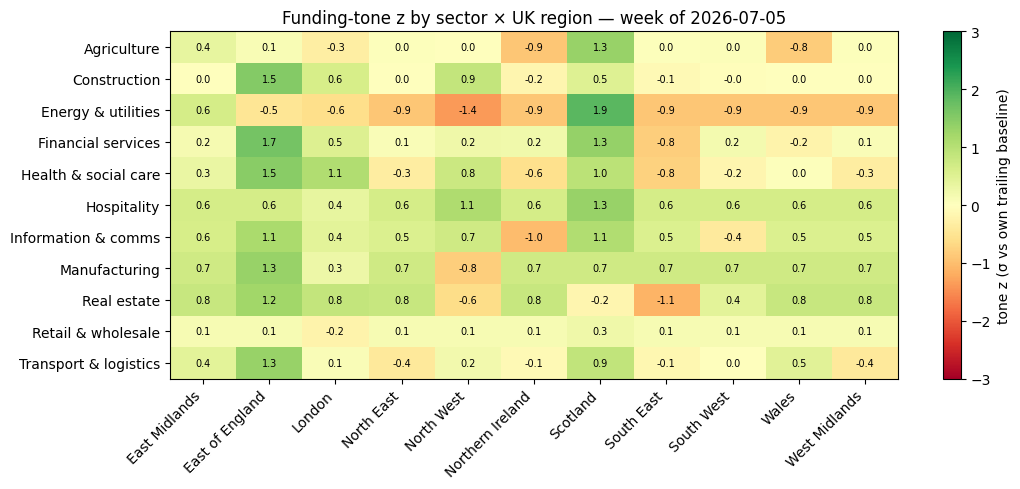

In [12]:
# ===========================================================================
# Part 4 — sector × region × week context-media index (joinable feature table)
# ===========================================================================
# Extends Part 3's single scan with Query B's V2Locations region rollup:
# GROUP BY sector, region, week in ONE aggregated query. BigQuery bills bytes
# scanned (columns × days), so the extra GROUP BY dimension is ~free — never
# loop per cell.
# Depends on the Part 3 cell (SECTOR_PATTERNS/_sector_cte, _safe_pat,
# FUNDING_PAT, BASE_WEEKS, bq_start, MIN_WEEKS, and `weekly` for the
# sector-only fallback) — run Part 3 first.
import numpy as np

# --- Part 4's OWN cache switch (independent of Part 3's USE_CACHE) ----------
# This is a SEPARATE ~180 GB scan from Part 3. Keeping its own switch means
# flipping Part 3's USE_CACHE=False to refresh the sector data does NOT also
# silently re-pull this region query. Set THIS to False only when you
# deliberately want to (re)build the region cache.
USE_CACHE_REGION = True   # True -> load the region Parquet (0 GB) if it exists

MIN_CELL_ARTICLES = 10   # region split thins cells; below this -> sector-only fallback
MAX_BASE_WEEKS    = 52   # trailing-baseline cap (fully used only once BASE_WEEKS=53)
REGION_CACHE = f"sector_region_weekly_cache_{BASE_WEEKS}w.parquet"
INDEX_FILE   = f"context_media_index_{BASE_WEEKS}w.parquet"

for _c in CITY_TO_REGION:                    # city names are interpolated into SQL
    assert re.fullmatch(r"[A-Za-z ]+", _c), f"unsafe city name: {_c!r}"
_region_cte = " UNION ALL ".join(
    f"SELECT '{c}' AS city, '{r}' AS region" for c, r in CITY_TO_REGION.items())

# Same filters as Part 3, plus: unnest V2Locations, keep UK city/ADM1 mentions,
# map city -> region in SQL. DISTINCT on GKGRECORDID so an article naming two
# cities in the SAME region counts once there (it can still appear in several
# regions/sectors — intended). Articles with only a country-level UK mention
# carry no region: absent here, but still inside Part 3's sector totals, which
# is exactly what the sector-only fallback is built from.
sql_cells = f"""
WITH sectors AS ( {_sector_cte} ),
regions AS ( {_region_cte} ),
matched AS (
  SELECT DISTINCT
    s.sector,
    r.region,
    g.GKGRECORDID AS id,
    PARSE_DATE('%Y%m%d', SUBSTR(CAST(g.DATE AS STRING), 1, 8)) AS day,
    DATE_TRUNC(PARSE_DATE('%Y%m%d', SUBSTR(CAST(g.DATE AS STRING), 1, 8)), WEEK) AS week,
    SAFE_CAST(SPLIT(g.V2Tone, ',')[SAFE_OFFSET(0)] AS FLOAT64) AS tone
  FROM {GKG} g
  CROSS JOIN sectors s
  CROSS JOIN UNNEST(SPLIT(g.V2Locations, ';')) AS loc
  JOIN regions r
    ON r.city = TRIM(SPLIT(SPLIT(loc, '#')[SAFE_OFFSET(1)], ',')[SAFE_OFFSET(0)])
  WHERE g._PARTITIONTIME >= TIMESTAMP(@pstart) AND g._PARTITIONTIME < TIMESTAMP(@pend)
    AND g.DATE >= @dstart AND g.DATE <= @dend
    AND SPLIT(loc, '#')[SAFE_OFFSET(2)] = 'UK'
    AND SAFE_CAST(SPLIT(loc, '#')[SAFE_OFFSET(0)] AS INT64) >= 3
    AND REGEXP_CONTAINS(LOWER(g.V2Themes), r'{_safe_pat(FUNDING_PAT)}')
    AND REGEXP_CONTAINS(LOWER(g.V2Themes), s.pat)
)
SELECT sector, region, week,
       COUNT(DISTINCT id) AS articles,
       COUNT(DISTINCT day) AS days,
       AVG(tone) AS avg_tone
FROM matched
GROUP BY sector, region, week
ORDER BY sector, region, week
"""

# Scan cost ≈ Part 3 + the small GKGRECORDID column. 26 wk ≈ ~90 GB; a full
# 53-wk pull (the target 52-week baseline) ≈ ~180 GB — hence max_gb=200.
# USE_CACHE_REGION (this cell's own switch) gates the scan — NOT Part 3's USE_CACHE.
if USE_CACHE_REGION and os.path.exists(REGION_CACHE):
    cells = pd.read_parquet(REGION_CACHE)
    print(f"Loaded {len(cells)} rows from cache '{REGION_CACHE}' (0 GB scanned). "
          "Set USE_CACHE_REGION=False to pull fresh data.")
else:
    cells = bq_query(sql_cells, params=date_params(bq_start, END_D), max_gb=200.0)
    cells.to_parquet(REGION_CACHE)
    print(f"Queried BigQuery and cached {len(cells)} rows -> '{REGION_CACHE}'.")

cells["week"]  = pd.to_datetime(cells["week"])
weekly["week"] = pd.to_datetime(weekly["week"])
cells["vol"]   = cells["articles"] / cells["days"].clip(lower=1)  # partial-week-safe


def trailing_z(s, window=MAX_BASE_WEEKS, min_weeks=MIN_WEEKS):
    """Point-in-time z: each week vs the <=52 trailing weeks that END the week before."""
    base = s.shift(1)                        # baseline excludes the scored week itself
    mean = base.rolling(window, min_periods=min_weeks).mean()
    std  = base.rolling(window, min_periods=min_weeks).std(ddof=0)
    return (s - mean) / std.replace(0, np.nan)


# Complete each series over the full week grid: a missing week = zero coverage
# (real volume signal, so vol=0); tone stays NaN (no articles -> no tone).
all_weeks = pd.date_range(weekly["week"].min(), weekly["week"].max(), freq="7D")


def complete_and_z(g):
    g = g.set_index("week").reindex(all_weeks)
    g.index.name = "week"
    g["articles"] = g["articles"].fillna(0).astype(int)
    g["vol"]      = g["vol"].fillna(0.0)
    g["tone_z"]   = trailing_z(g["avg_tone"])
    g["vol_z"]    = trailing_z(g["vol"])
    return g.reset_index()


# 1) per-(sector, region) cell z-scores — every week, not just the latest,
#    because the training table joins at each firm's cutoff week.
frames = []
for (sec, reg), g in cells.groupby(["sector", "region"]):
    z = complete_and_z(g)
    z["sector"], z["region"] = sec, reg
    frames.append(z)
cell_z = pd.concat(frames, ignore_index=True)

# 2) sector-only z-scores from Part 3's `weekly` = the thin-cell fallback
sframes = []
for sec, g in weekly.groupby("sector"):
    z = complete_and_z(g)[["week", "tone_z", "vol_z"]]
    z.columns = ["week", "tone_z_sector", "vol_z_sector"]
    z["sector"] = sec
    sframes.append(z)
sector_z = pd.concat(sframes, ignore_index=True)

# 3) fall back where the cell is thin (few articles) or lacks a usable baseline
idx = cell_z.merge(sector_z, on=["sector", "week"], how="left")
thin = idx["tone_z"].isna() | (idx["articles"] < MIN_CELL_ARTICLES)
idx["z_source"] = np.where(thin, "sector-fallback", "cell")
idx["tone_z"]   = idx["tone_z"].where(~thin, idx["tone_z_sector"])
idx["vol_z"]    = idx["vol_z"].where(~thin, idx["vol_z_sector"])

media_index = (idx[["sector", "region", "week", "articles", "tone_z", "vol_z", "z_source"]]
               .dropna(subset=["tone_z", "vol_z"], how="all")
               .sort_values(["week", "sector", "region"]).reset_index(drop=True))
media_index.to_parquet(INDEX_FILE, index=False)

fb = (media_index["z_source"] == "sector-fallback").mean()
print(f"\nContext-media index: {len(media_index)} (sector, region, week) rows -> '{INDEX_FILE}'")
print("Feature-table join key: (SIC group -> sector, region, cutoff week).")
print(f"Sector-only fallback used on {fb:.0%} of rows (a cell needs >= "
      f"{MIN_CELL_ARTICLES} articles and a >= {MIN_WEEKS}-week baseline).")

# Latest-week heatmap. Within a gated single-sector list it's the REGION
# variation (one row here) that differentiates firms — that's the signal.
latest_week = media_index["week"].max()
pv = (media_index[media_index["week"] == latest_week]
      .pivot(index="sector", columns="region", values="tone_z"))
if not pv.empty:
    fig, ax = plt.subplots(figsize=(11, 5))
    im = ax.imshow(pv.values.astype(float), cmap="RdYlGn", vmin=-3, vmax=3, aspect="auto")
    ax.set_xticks(range(len(pv.columns)))
    ax.set_xticklabels(pv.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pv.index)))
    ax.set_yticklabels(pv.index)
    for i in range(pv.shape[0]):
        for j in range(pv.shape[1]):
            v = pv.values[i, j]
            if v == v:                       # skip NaN cells
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, label="tone z (σ vs own trailing baseline)")
    ax.set_title(f"Funding-tone z by sector × UK region — week of {latest_week.date()}")
    plt.tight_layout(); plt.show()

In [14]:
import pandas as pd
media_index = pd.read_parquet("context_media_index_53w.parquet")   # from the API/ folder
media_index[["sector", "region", "week", "tone_z", "vol_z"]]

,sector,region,week,tone_z,vol_z
0,Agriculture,East Midlands,2025-09-21,-0.551059,3.764237
1,Agriculture,East of England,2025-09-21,-0.019358,5.03796
2,Agriculture,London,2025-09-21,1.282120,1.788945
3,Agriculture,North East,2025-09-21,1.009662,0.028496
4,Agriculture,North West,2025-09-21,1.560573,4.766214
...,...,...,...,...,...
5077,Transport & logistics,Scotland,2026-07-05,0.867592,-0.669381
5078,Transport & logistics,South East,2026-07-05,-0.147145,-0.119883
5079,Transport & logistics,South West,2026-07-05,0.021299,-0.206198
5080,Transport & logistics,Wales,2026-07-05,0.453917,-0.26676


## Part 5 · Company postcode → town + region (the join key to the media index)

The Part 4 index is keyed by `(sector, region, week)`, so every company needs a **region** on the
same 12 labels before it can join. This cell derives that from each firm's **registered-office
postcode** using **[postcodes.io](https://postcodes.io)** (free, keyless, bulk ≤100/call) and writes
two new columns into `final_7_7_26.csv`:

- **`town_api`** — the postcode's local-authority district (postcodes.io `admin_district`, e.g.
  `Camden`, `Leeds`, `Aberdeen City`). A town/city proxy that complements the existing Companies-House
  `town` (Royal-Mail post town).
- **`region`** — mapped onto the **exact same 12 labels as `CITY_TO_REGION`** so it joins straight to
  the media index.

**Region mapping.** postcodes.io's `region` is an England-only ONS field, so:
- England → use `region`, renaming `"Yorkshire and The Humber"` → `"Yorkshire"` to match the GDELT label.
- Scotland / Wales / Northern Ireland (where `region` is null) → use `country`.

**Two passes for coverage.** The bulk endpoint resolves live postcodes; a small **outcode fallback**
(`/outcodes/{outcode}` + a district→region map learned from the resolved rows) recovers terminated /
large-user postcodes (e.g. `EC2Y`, `W1A`). On this file that took coverage from 99.1% → **99.6%**
(13,491 / 13,544); the residual are blank or genuinely defunct postcodes (`W1R`, `CF1`, …).

> 🔁 **Idempotent:** with `FORCE_REFRESH = False` the cell skips the API entirely once the two columns
> already exist (0 calls), mirroring the `USE_CACHE` pattern in Parts 3–4. Flip to `True` to re-pull.

⚠️ **`region` here is the registered-office region** — the point-in-time location you join on. Note it
is the *legal* address, which for some firms differs from where they actually trade.

In [15]:
# ===========================================================================
# Part 5 — enrich the SME company table with town + GDELT region (postcodes.io)
# ===========================================================================
# Adds two columns to final_7_7_26.csv so it can join to the Part 4 media index:
#   town_api : local-authority town from the postcode (postcodes.io admin_district)
#   region   : mapped onto the SAME 12 labels as CITY_TO_REGION / media_index
# postcodes.io is free & keyless; the bulk endpoint resolves <=100 postcodes/call.
import time
import requests
import pandas as pd

COMPANY_CSV  = "CompaniesHouse/company_data/final_7_7_26.csv"   # relative to API/
FORCE_REFRESH = False   # True -> re-hit the API even if town_api/region already exist

# postcodes.io 'region' is England-only (ONS ITL1); Scotland/Wales/NI come via
# 'country'. Normalise BOTH onto the 12 GDELT labels (CITY_TO_REGION values) so
# the column is directly joinable to the media index.
COUNTRY_AS_REGION = {"Scotland", "Wales", "Northern Ireland"}
REGION_RENAME = {"Yorkshire and The Humber": "Yorkshire"}   # match the GDELT label


def _to_gdelt_region(region, country):
    """Map a postcodes.io (region, country) pair onto a GDELT region label."""
    if country in COUNTRY_AS_REGION:
        return country
    if region is None:
        return None
    return REGION_RENAME.get(region, region)     # England ONS names already align


def resolve_postcodes(postcodes, chunk=100, pause=0.15, session=None):
    """Bulk-resolve UK postcodes -> {postcode: (town, region)} via postcodes.io.

    Uses the bulk POST endpoint (<=100/call). town = admin_district; region is
    GDELT-mapped. Unknown/terminated postcodes -> (None, None) here (recovered in
    the outcode fallback below).
    """
    s = session or requests.Session()
    out = {}
    for i in range(0, len(postcodes), chunk):
        batch = postcodes[i:i + chunk]
        for attempt in range(4):
            try:
                r = s.post("https://api.postcodes.io/postcodes",
                           json={"postcodes": batch}, timeout=30)
                r.raise_for_status()
                break
            except requests.RequestException:
                if attempt == 3:
                    raise
                time.sleep(2 ** attempt)         # backoff on transient errors
        for item in r.json()["result"]:
            res = item["result"]
            out[item["query"]] = ((res.get("admin_district"),
                                   _to_gdelt_region(res.get("region"), res.get("country")))
                                  if res else (None, None))
        print(f"  resolved {min(i + chunk, len(postcodes))}/{len(postcodes)}", end="\r")
        time.sleep(pause)                        # be polite to the free API
    print()
    return out


def resolve_via_outcode(postcodes, district_to_region, session=None, pause=0.1):
    """Fallback for terminated / large-user postcodes: outcode -> (town, region).

    The /outcodes endpoint has no ONS region, but returns admin_district + country
    at outward-code level. Region for England is inferred from a district->region
    map learned from the rows the bulk pass already resolved (1 LA -> 1 region).
    """
    s = session or requests.Session()
    out = {}
    for p in postcodes:
        outcode = p.split(" ")[0]
        try:
            r = s.get(f"https://api.postcodes.io/outcodes/{outcode}", timeout=30)
        except requests.RequestException:
            continue
        if r.status_code != 200:
            continue
        res = r.json().get("result") or {}
        dists = res.get("admin_district") or []
        ctys  = res.get("country") or []
        town = dists[0] if dists else None
        country = ctys[0] if ctys else None
        region = (country if country in COUNTRY_AS_REGION
                  else next((district_to_region[d] for d in dists
                             if d in district_to_region), None))
        out[p] = (town, region)
        time.sleep(pause)
    return out


df = pd.read_csv(COMPANY_CSV, dtype=str)
already_done = {"town_api", "region"}.issubset(df.columns) and df["region"].notna().any()

if already_done and not FORCE_REFRESH:
    print(f"'{COMPANY_CSV}' already has town_api/region — skipping the API "
          f"(region filled on {df['region'].notna().sum()}/{len(df)} rows). "
          "Set FORCE_REFRESH=True to re-pull.")
else:
    # postcodes.io matches on canonical spacing/case; normalise the query key to match.
    pc_key = df["post_code"].fillna("").str.strip().str.upper()
    uniq = sorted(set(pc_key) - {""})
    print(f"Resolving {len(uniq)} unique postcodes via postcodes.io ...")
    mapping = resolve_postcodes(uniq)

    # key the mapping on what we SENT (API canonicalises spacing), then map back.
    df["town_api"] = pc_key.map(lambda p: mapping.get(p, (None, None))[0])
    df["region"]   = pc_key.map(lambda p: mapping.get(p, (None, None))[1])

    # fallback pass for postcodes the live endpoint couldn't resolve
    miss = df["region"].isna() & (pc_key != "")
    miss_pc = sorted(set(pc_key[miss]))
    if miss_pc:
        d2r = (df.dropna(subset=["town_api", "region"])
                 .drop_duplicates("town_api").set_index("town_api")["region"].to_dict())
        print(f"Outcode fallback for {len(miss_pc)} unresolved postcodes ...")
        fill = resolve_via_outcode(miss_pc, d2r)
        for i in df.index[miss]:
            town, region = fill.get(pc_key[i], (None, None))
            if pd.isna(df.at[i, "town_api"]) and town:
                df.at[i, "town_api"] = town
            if pd.isna(df.at[i, "region"]) and region:
                df.at[i, "region"] = region

    df.to_csv(COMPANY_CSV, index=False)
    print(f"Wrote '{COMPANY_CSV}' with columns town_api + region.")

# --- summary (runs either way) ---------------------------------------------
pc_present = df["post_code"].fillna("").str.strip() != ""
print(f"\nregion filled: {df['region'].notna().sum()}/{len(df)}  "
      f"(blank postcode: {(~pc_present).sum()}; "
      f"unresolved w/ postcode: {(df['region'].isna() & pc_present).sum()})")
print("\nCompanies per GDELT region:")
print(df["region"].value_counts(dropna=False).to_string())

'CompaniesHouse/company_data/final_7_7_26.csv' already has town_api/region — skipping the API (region filled on 13491/13544 rows). Set FORCE_REFRESH=True to re-pull.

region filled: 13491/13544  (blank postcode: 49; unresolved w/ postcode: 4)

Companies per GDELT region:
region
London              5109
South East          2369
South West          1475
East of England     1142
North West           880
West Midlands        639
Yorkshire            567
East Midlands        461
Scotland             369
Wales                208
North East           184
Northern Ireland      88
NaN                   53


## Part 6 · Join the media index onto the companies → `11_7_26_with_context_media.csv`

The final wiring: attach each firm's **`tone_z` / `vol_z`** from the Part 4 index by matching on
`(sector, region, week)`, and write the result to `11_7_26_with_context_media.csv`.

**The three join keys, and where each comes from:**
- **`region`** — from Part 5 (postcode → region).
- **`sector`** — mapped here from `sic_code`'s 2-digit **SIC division** onto the 11 GDELT sector groups
  (`SIC_DIVISION_TO_SECTOR`). The GDELT sectors don't cover every SIC (professional services, admin,
  education, etc. have no group), so this maps only a subset. **SIC 98 → *Real estate*** (these are
  overwhelmingly resident/flat property-management companies), which lifts sector coverage 49% → **80%**.
- **`week`** — a single **snapshot week** (the latest week in the index, `2026-07-05`) applied to every
  company: the *score-as-of-now* deployment scenario. Set `JOIN_WEEK` to a date to pin a different
  cutoff (e.g. for temporal validation); it is floored to the Sunday grid.

**Coverage.** ~**76%** of firms (10,350 / 13,544) get media features. The rest are `media_missing = 1`:
mostly unmapped SIC divisions (~2,700), then Yorkshire firms (no GDELT cell — the known city-match gap),
then blank/invalid postcodes.

**New columns written:** `sector`, `week`, `tone_z`, `vol_z`, `z_source`, `media_missing`.

> This is a **left join** — no company is dropped; unmatched firms carry `NaN` z-scores and
> `media_missing = 1`, which the model can treat as its own signal (see the ablation discussion).


In [ ]:
# ===========================================================================
# Part 6 — join the media index onto the companies -> 11_7_26_with_context_media.csv
# ===========================================================================
# Attach each firm's tone_z / vol_z from the Part 4 index by (sector, region, week).
import pandas as pd

COMPANY_CSV      = "CompaniesHouse/company_data/11_7_26_with_context_media.csv"  # rel. to API/
MEDIA_INDEX_FILE = "context_media_index_53w.parquet"
JOIN_WEEK = None   # None -> latest week in the index (score-as-of-now); or "YYYY-MM-DD"

# SIC 2-digit DIVISION -> GDELT sector group. The 11 GDELT sectors don't cover
# every SIC (professional services / admin / education have no group), so only a
# subset maps. SIC 98 (resident property-management cos.) -> Real estate.
SIC_DIVISION_TO_SECTOR = {}
def _add(rng, sector):
    for d in rng:
        SIC_DIVISION_TO_SECTOR[f"{d:02d}"] = sector
_add(range(1, 4),   "Agriculture")
_add(range(5, 10),  "Energy & utilities")     # mining / quarrying (extractive)
_add(range(10, 34), "Manufacturing")
_add(range(35, 40), "Energy & utilities")     # electricity / gas / water / waste
_add(range(41, 44), "Construction")
_add(range(45, 48), "Retail & wholesale")
_add(range(49, 54), "Transport & logistics")
_add(range(55, 57), "Hospitality")
_add(range(58, 64), "Information & comms")
_add(range(64, 67), "Financial services")
SIC_DIVISION_TO_SECTOR["68"] = "Real estate"
_add(range(86, 89), "Health & social care")
SIC_DIVISION_TO_SECTOR["98"] = "Real estate"  # resident property-management companies

df = pd.read_csv(COMPANY_CSV, dtype=str)
media_index = pd.read_parquet(MEDIA_INDEX_FILE)
media_index["week"] = pd.to_datetime(media_index["week"])

# 1) sic_code -> sector (2-digit division lookup)
df["sector"] = df["sic_code"].astype(str).str.strip().str[:2].map(SIC_DIVISION_TO_SECTOR)

# 2) join week = one snapshot week (latest available, or the pinned JOIN_WEEK)
if JOIN_WEEK is None:
    join_week = media_index["week"].max()
else:
    d = pd.to_datetime(JOIN_WEEK)
    join_week = d - pd.Timedelta(days=(d.dayofweek + 1) % 7)   # floor to Sunday grid
df["week"] = join_week

# 3) left-join tone_z / vol_z on (sector, region, week) — no firm is dropped.
#    Drop any media columns from a previous run first, so re-running is idempotent.
df = df.drop(columns=[c for c in ["tone_z", "vol_z", "z_source", "media_missing"]
                      if c in df.columns])
slice_ = media_index.loc[media_index["week"] == join_week,
                         ["sector", "region", "week", "tone_z", "vol_z", "z_source"]]
out = df.merge(slice_, on=["sector", "region", "week"], how="left")
out["media_missing"] = out["tone_z"].isna().astype(int)

out.to_csv(COMPANY_CSV, index=False)

# --- report ----------------------------------------------------------------
have = out["tone_z"].notna()
miss = out[~have]
print(f"Join week: {join_week.date()}   media index: '{MEDIA_INDEX_FILE}'")
print(f"sector mapped:         {df['sector'].notna().sum():>6}/{len(df)} "
      f"({df['sector'].notna().mean():.0%})")
print(f"media features filled: {have.sum():>6}/{len(out)} ({have.mean():.0%})")
print(f"  missing -> no sector: {miss['sector'].isna().sum()} | "
      f"no region: {miss['region'].isna().sum()} | "
      f"sector+region but no cell (e.g. Yorkshire): "
      f"{((miss['sector'].notna()) & (miss['region'].notna())).sum()}")
print(f"\nWrote '{COMPANY_CSV}'  (+ sector, week, tone_z, vol_z, z_source, media_missing)")
print(out.loc[have, ['name', 'sic_code', 'sector', 'region',
                     'tone_z', 'vol_z', 'z_source']].head(6).to_string(index=False))
